# 05 - Comparaison Corr vs ModelSelection
## Objectif : Comparer les deux méthodes de preprocessing et choisir la meilleure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
print('✅ Imports OK')

✅ Imports OK


## 1. Charger les deux datasets

In [2]:
TARGET          = 'total_sales'
TARGETS_CASCADE = ['nb_clients', 'nb_documents', 'total_quantity']

datasets = {
    'corr':   {
        'df':       pd.read_csv('/app/notebooks/ml_dataset_corr.csv', parse_dates=['date']),
        'features': json.load(open('/app/notebooks/base_features_corr.json')),
    },
    'modsel': {
        'df':       pd.read_csv('/app/notebooks/ml_dataset_modsel.csv', parse_dates=['date']),
        'features': json.load(open('/app/notebooks/base_features_modsel.json')),
    }
}

for method, data in datasets.items():
    print(f'\n{method.upper()}')
    print(f'  Dataset shape : {data["df"].shape}')
    print(f'  BASE_FEATURES : {data["features"]}')


CORR
  Dataset shape : (43, 25)
  BASE_FEATURES : ['lag_1', 'lag_2', 'rolling_mean_3']

MODSEL
  Dataset shape : (43, 25)
  BASE_FEATURES : ['month', 'quarter', 'semester', 'is_end_year', 'is_january', 'lag_2', 'lag_3', 'rolling_mean_6']


## 2. Évaluer les deux méthodes avec pipeline cascade

In [3]:
def run_cascade_pipeline(df_ml, BASE_FEATURES, method_name):
    BASE_FEATURES = [f for f in BASE_FEATURES if f in df_ml.columns]
    split_idx = int(len(df_ml) * 0.85)
    df_train = df_ml.iloc[:split_idx].copy()
    df_test  = df_ml.iloc[split_idx:].copy()

    # Entraîner modèles cascade
    cascade_models  = {}
    cascade_scalers = {}
    for tv in TARGETS_CASCADE:
        sc = StandardScaler()
        X_tr_sc = sc.fit_transform(df_train[BASE_FEATURES])
        m = Ridge(alpha=10)
        m.fit(X_tr_sc, df_train[tv])
        cascade_models[tv]  = m
        cascade_scalers[tv] = sc

    # Augmenter avec prédictions
    PRED_VARS = []
    for tv in TARGETS_CASCADE:
        pred_col = f'{tv}_pred'
        PRED_VARS.append(pred_col)
        m  = cascade_models[tv]
        sc = cascade_scalers[tv]
        df_train[pred_col] = m.predict(sc.transform(df_train[BASE_FEATURES]))
        df_test[pred_col]  = m.predict(sc.transform(df_test[BASE_FEATURES]))

    FINAL_FEATURES = BASE_FEATURES + PRED_VARS

    X_train = df_train[FINAL_FEATURES]
    X_test  = df_test[FINAL_FEATURES]
    y_train = df_train[TARGET]
    y_test  = df_test[TARGET]

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    models_config = [
        ('LinearRegression', LinearRegression(),                                                    X_train_sc, X_test_sc),
        ('Ridge',            Ridge(alpha=10),                                                       X_train_sc, X_test_sc),
        ('DecisionTree',     DecisionTreeRegressor(max_depth=3, random_state=42),                  X_train,    X_test),
        ('RandomForest',     RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),X_train,    X_test),
        ('XGBoost',          XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.03, random_state=42), X_train, X_test),
    ]

    results = []
    for name, model, Xtr, Xte in models_config:
        model.fit(Xtr, y_train)
        pred  = model.predict(Xte)
        mae   = mean_absolute_error(y_test, pred)
        rmse  = np.sqrt(mean_squared_error(y_test, pred))
        r2    = r2_score(y_test, pred)
        mape  = np.mean(np.abs((y_test - pred) / y_test)) * 100
        smape = np.mean(2 * np.abs(y_test - pred) / (np.abs(y_test) + np.abs(pred))) * 100
        bias  = np.mean(pred - y_test)
        results.append({'Méthode': method_name, 'Modèle': name, 'pred': pred,
                        'MAE': mae, 'RMSE': rmse, 'R²': r2,
                        'MAPE': mape, 'SMAPE': smape, 'Biais': bias})
    return pd.DataFrame(results)

# Exécuter pour les deux méthodes
df_corr   = run_cascade_pipeline(datasets['corr']['df'].copy(),   datasets['corr']['features'],   'CORR')
df_modsel = run_cascade_pipeline(datasets['modsel']['df'].copy(), datasets['modsel']['features'], 'MODSEL')

df_all = pd.concat([df_corr, df_modsel], ignore_index=True)
print('✅ Évaluation terminée')

✅ Évaluation terminée


## 3. Tableau comparatif complet

In [4]:
df_display = df_all[['Méthode', 'Modèle', 'MAE', 'RMSE', 'R²', 'MAPE', 'SMAPE', 'Biais']].copy()

print('=' * 90)
print(f'{"Méthode":<8} {"Modèle":<20} {"MAE":>10} {"RMSE":>10} {"R²":>8} {"MAPE":>8} {"SMAPE":>8} {"Biais":>12}')
print('=' * 90)
for _, row in df_display.iterrows():
    print(f'{row["Méthode"]:<8} {row["Modèle"]:<20} '
          f'{row["MAE"]:>10,.0f} {row["RMSE"]:>10,.0f} '
          f'{row["R²"]:>8.4f} {row["MAPE"]:>7.2f}% '
          f'{row["SMAPE"]:>7.2f}% {row["Biais"]:>12,.0f}')
print('=' * 90)

best_idx    = df_all['MAPE'].idxmin()
best_method = df_all.loc[best_idx, 'Méthode']
best_model  = df_all.loc[best_idx, 'Modèle']
best_mape   = df_all.loc[best_idx, 'MAPE']

print(f'\n🏆 MEILLEURE COMBINAISON : {best_method} + {best_model} (MAPE = {best_mape:.2f}%)')

Méthode  Modèle                      MAE       RMSE       R²     MAPE    SMAPE        Biais
CORR     LinearRegression        201,369    217,100  -0.9423   13.51%   13.79%      -43,421
CORR     Ridge                   177,466    199,535  -0.6407   11.83%   12.21%      -66,759
CORR     DecisionTree            171,934    200,663  -0.6593   11.38%   11.85%      -80,909
CORR     RandomForest            186,315    226,923  -1.1221   11.93%   12.87%     -148,160
CORR     XGBoost                 216,077    254,016  -1.6590   13.90%   15.14%     -164,540
MODSEL   LinearRegression        144,050    199,454  -0.6394    9.25%    9.98%      -79,935
MODSEL   Ridge                   134,769    176,299  -0.2809    8.67%    9.23%      -84,994
MODSEL   DecisionTree            203,460    274,799  -2.1119   12.69%   14.33%     -193,426
MODSEL   RandomForest            189,902    228,936  -1.1599   12.11%   13.19%     -167,403
MODSEL   XGBoost                 200,947    255,579  -1.6919   12.81%   14.17%  

## 4. Visualisation comparative

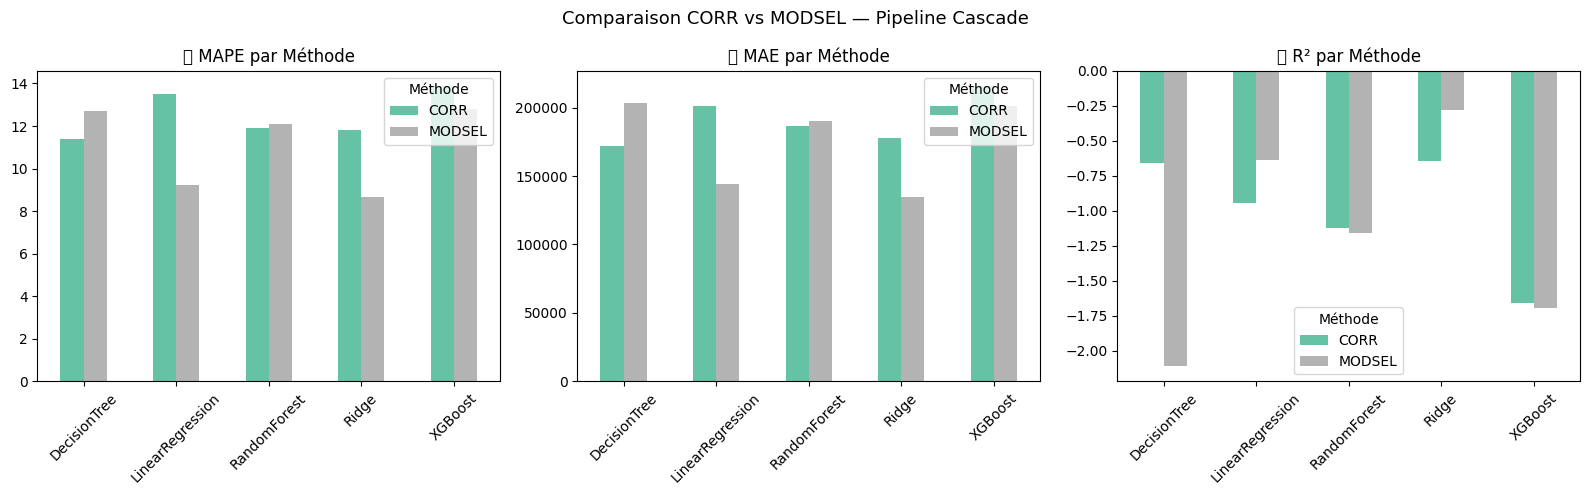


✅ Conclusion : utiliser MODSEL + Ridge
   → Relancer 03_CascadeTraining avec PREP_METHOD = "modsel"
   → Puis 04_Prediction


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['MAPE', 'MAE', 'R²']):
    pivot = df_display.pivot(index='Modèle', columns='Méthode', values=metric)
    pivot.plot(kind='bar', ax=ax, colormap='Set2')
    ax.set_title(f'📊 {metric} par Méthode')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Méthode')

plt.suptitle('Comparaison CORR vs MODSEL — Pipeline Cascade', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\n✅ Conclusion : utiliser {best_method} + {best_model}')
print(f'   → Relancer 03_CascadeTraining avec PREP_METHOD = "{best_method.lower()}"')
print(f'   → Puis 04_Prediction')